Load the libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

Load the data

In [2]:
data = pd.read_csv("netflix_titles.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


Summary of the data

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


Insights: 
- we have 6234 entities. Any column less than that entities, containes missing values
[Director, Cast, Country, Date Added]

- Data type inconsistency
[date_added is an object]

- Number of columns: 12


Data Cleaning and Transformation

In [5]:
data.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

Handling Director, Country and Cast's null values

In [6]:
data["director"] = data["director"].fillna("Unknown")
data["cast"] = data['cast'].fillna("Unknown")
data["country"] = data['country'].fillna("Unknown")

Handling Date_Added, duration, rating null values

In [7]:
data.dropna(subset=['date_added', 'rating', 'duration'], inplace = True)

Convert datatype of date_added from object to datetime objects

In [8]:
data["date_added"] =  pd.to_datetime(data["date_added"], format="mixed", dayfirst=False)

New Feature for year_added and month_added

In [9]:
data["Year_added"] = data['date_added'].dt.year
data["Month_added"] = data['date_added'].dt.month

In [49]:
data['release_delay'] = data['date_added'].dt.year - data['release_year']
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added,Month_added,release_delay
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019,9,0
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016,9,0
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018,9,5
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018,9,2
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017,9,0


In [10]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'Year_added', 'Month_added'],
      dtype='object')

Checking Missing Values and Data Transformation

In [11]:
print("Missing Values")
print(data.isnull().sum())
print('\nDataType after transformation')
print(data.dtypes)

Missing Values
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
Year_added      0
Month_added     0
dtype: int64

DataType after transformation
show_id                  int64
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
Year_added               int32
Month_added              int32
dtype: object


EDA

In [12]:
type_counts = data['type'].value_counts()
print(type_counts)

type
Movie      4257
TV Show    1957
Name: count, dtype: int64


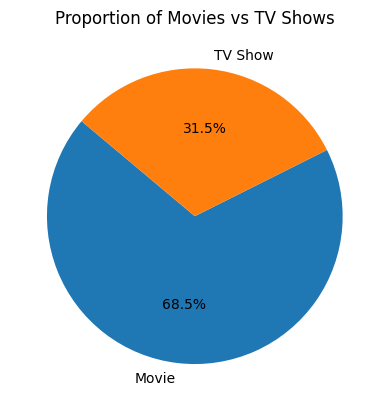

In [13]:
plt.pie(type_counts, labels = type_counts.index, autopct= '%1.1f%%', startangle = 140)
plt.title('Proportion of Movies vs TV Shows')
plt.ylabel("")
plt.savefig("Proportion of movies vs TV Shows.png")
plt.show()

Insights: 
   - Netflix library is highly dominated by Movies making up roughly 70% of the content in this dataset

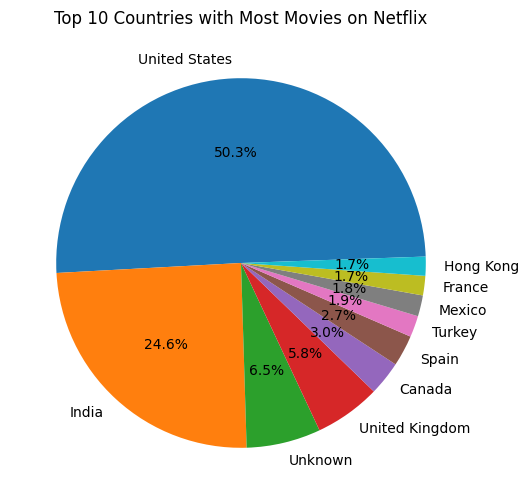

In [ ]:
movie = data[data['type'] == 'Movie']

country_share = movie['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.pie(
    country_share,
    labels=country_share.index,
    autopct='%1.1f%%',
    startangle=2
)
plt.title('Top 10 Countries with Most Movies on Netflix')
plt.savefig("Top 10 Countries with Most Movies on Netflix.png")


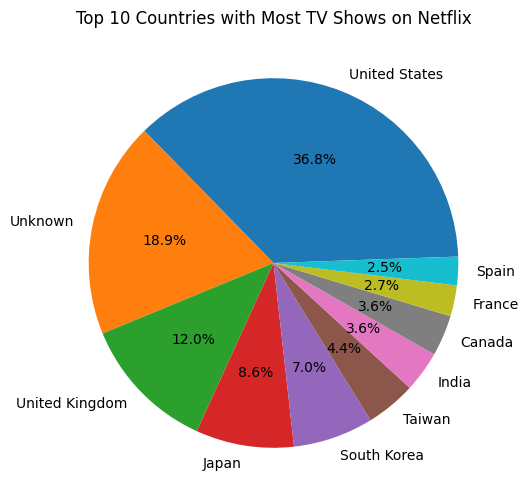

In [24]:
movie = data[data['type'] == 'TV Show']

country_share = movie['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.pie(
    country_share,
    labels=country_share.index,
    autopct='%1.1f%%',
    startangle=2
)
plt.title('Top 10 Countries with Most TV Shows on Netflix')
plt.savefig("Top 10 Countries with Most TV Shows on Netflix.png")


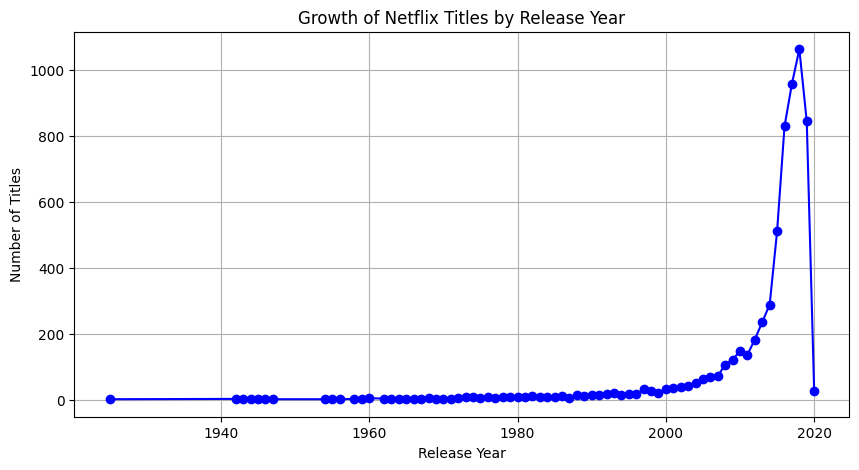

In [26]:
growth = data['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.plot(growth.index, growth.values, marker='o', color='blue')

plt.title("Growth of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.savefig("Growth of Netflix Titles by Release Year.png")
plt.show()

date_added
2008       1
2009       2
2010       1
2011      13
2012       4
2013       6
2014      19
2015      56
2016     262
2017     910
2018    1290
2019    1546
2020     147
dtype: int64


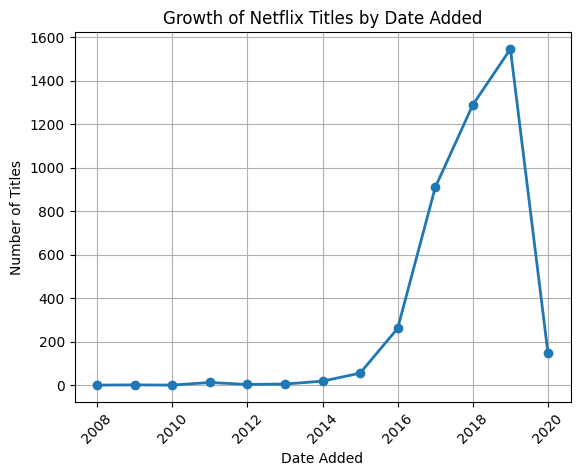

In [30]:
movies = data[data['type'] == 'Movie']

movies_per_year = movies.groupby(movies['date_added'].dt.year).size()

print(movies_per_year)

plt.plot(
    movies_per_year.index,
    movies_per_year.values,
    marker='o',
    linewidth=2
)
plt.title("Growth of Netflix Titles by Date Added")
plt.xlabel("Date Added")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.xticks(rotation=45)
plt.savefig("Growth of Netflix Titles by Date Added.png")
plt.show()

In [32]:
start_year = movies_per_year.index.min()
end_year = movies_per_year.index.max()

beginning = movies_per_year.loc[start_year]
ending = movies_per_year.loc[end_year]

n = end_year - start_year

cagr = ((ending / beginning) ** (1 / n) - 1) * 100

print(f"CAGR: {cagr:.2f}%")

CAGR: 51.57%


date_added
2008            NaN
2009     100.000000
2010     -50.000000
2011    1200.000000
2012     -69.230769
2013      50.000000
2014     216.666667
2015     194.736842
2016     367.857143
2017     247.328244
2018      41.758242
2019      19.844961
2020     -90.491591
dtype: float64


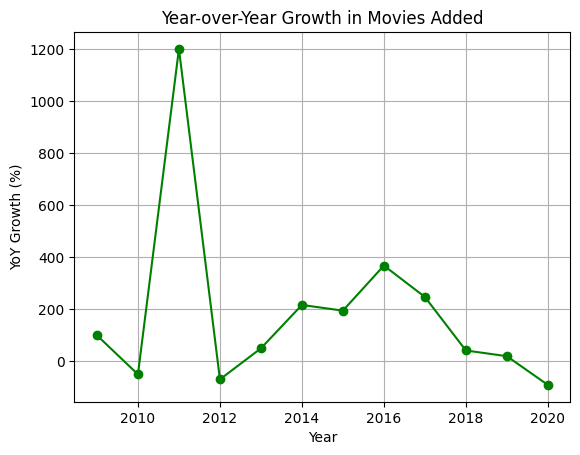

In [35]:
yoy_growth = movies_per_year.pct_change() *100
print(yoy_growth)

plt.figsize=(10, 5)
plt.plot(
    yoy_growth.index, 
    yoy_growth.values,
    marker='o',
    color  = 'green'
)
plt.title("Year-over-Year Growth in Movies Added")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")
plt.savefig("Year-over-Year Growth in Movies Added.png")
plt.grid()

<Figure size 1200x600 with 0 Axes>

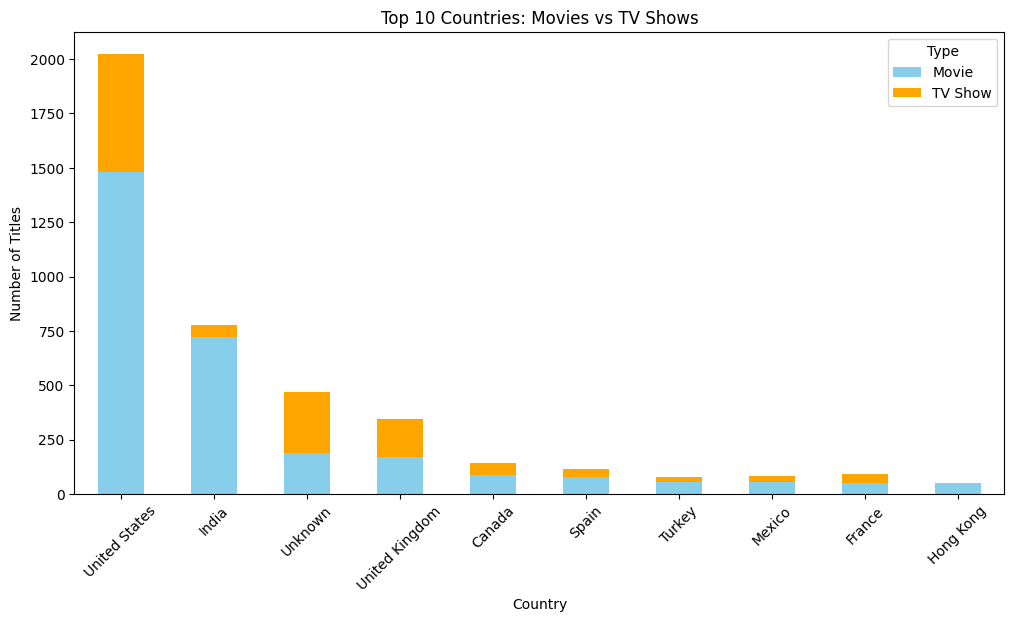

In [43]:
country_type = data.groupby('country')['type'].value_counts().unstack()
top_10 = country_type.sort_values(by = ['Movie', 'TV Show'], ascending=False).head(10)
plt.figure(figsize=(12, 6))
top_10.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['skyblue', 'orange']
)
plt.title("Top 10 Countries: Movies vs TV Shows")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.savefig("Top 10 Countries: Movies vs TV Shows.png")

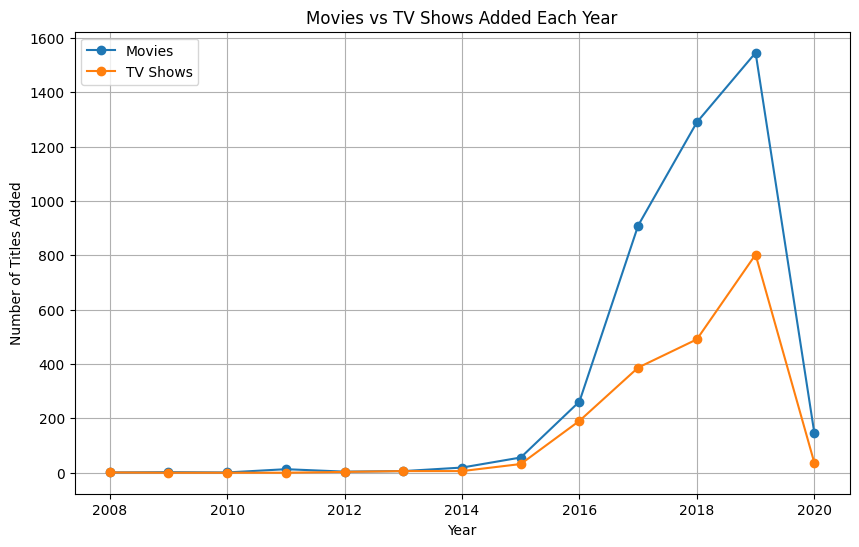

In [45]:
yearly = data.groupby([data['date_added'].dt.year, 'type']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))

plt.plot(yearly.index, yearly['Movie'], marker='o', label='Movies')
plt.plot(yearly.index, yearly['TV Show'], marker='o', label='TV Shows')

plt.title("Movies vs TV Shows Added Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.legend()
plt.grid(True)
plt.savefig("Movies vs TV Shows Added Each Year.png")
plt.show()

In [51]:
average_delay = data['release_delay'].mean()
print(f"Average Release Delay: {average_delay:.2f} years")

Average Release Delay: 4.63 years


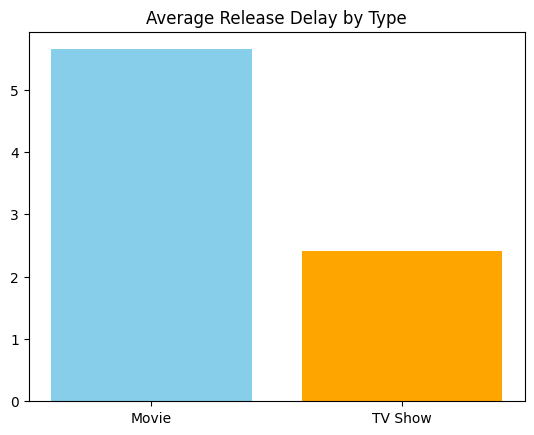

In [53]:
average_delay_by_type = data.groupby('type')['release_delay'].mean()
plt.bar(average_delay_by_type.index, average_delay_by_type.values, color=['skyblue', 'orange'])
plt.title("Average Release Delay by Type")  
plt.savefig("Average Release Delay by Type.png")

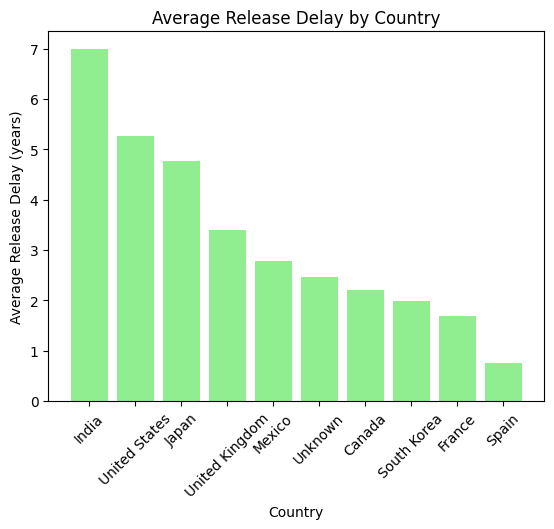

In [63]:
top_10_countries = data['country'].value_counts().head(10)
average_delay_by_country = data[data['country'].isin(top_10_countries.index)].groupby('country')['release_delay'].mean().sort_values(ascending=False)
plt.bar(average_delay_by_country.index, average_delay_by_country.values, color='lightgreen')
plt.title("Average Release Delay by Country")  
plt.xlabel("Country")
plt.ylabel("Average Release Delay (years)")
plt.xticks(rotation=45)

plt.savefig("Average Release Delay by Country.png")

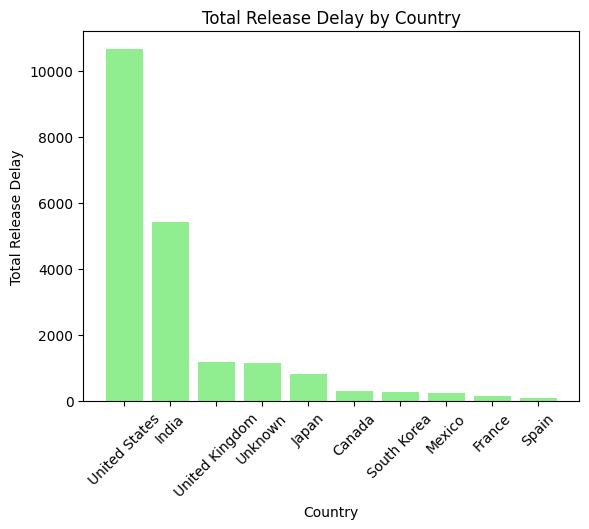

In [65]:
top_10_countries = data['country'].value_counts().head(10)
total_delay_by_country = data[data['country'].isin(top_10_countries.index)].groupby('country')['release_delay'].sum().sort_values(ascending=False)
plt.bar(total_delay_by_country.index, total_delay_by_country.values, color='lightgreen')
plt.title("Total Release Delay by Country")  
plt.xlabel("Country")
plt.ylabel("Total Release Delay")
plt.xticks(rotation=45)

plt.savefig("Total Release Delay by Country.png")

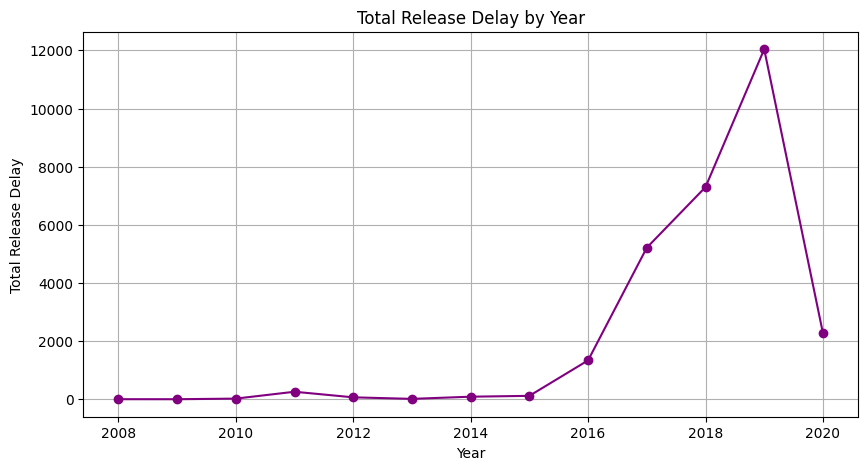

In [70]:
delay_per_year = data.groupby(data['date_added'].dt.year)['release_delay'].sum()

plt.figure(figsize=(10, 5))
plt.plot(delay_per_year.index, delay_per_year.values, marker='o', color='purple')

plt.title("Total Release Delay by Year")
plt.xlabel("Year")
plt.ylabel("Total Release Delay")
plt.grid(True)
plt.savefig("Total Release Delay by Year.png")
plt.show()

listed_in
International Movies      1927
Dramas                    1622
Comedies                  1113
International TV Shows     999
Documentaries              668
TV Dramas                  598
Action & Adventure         597
Independent Movies         552
TV Comedies                428
Thrillers                  392
Name: count, dtype: int64


Text(0.5, -109.27777777777779, 'Genre')

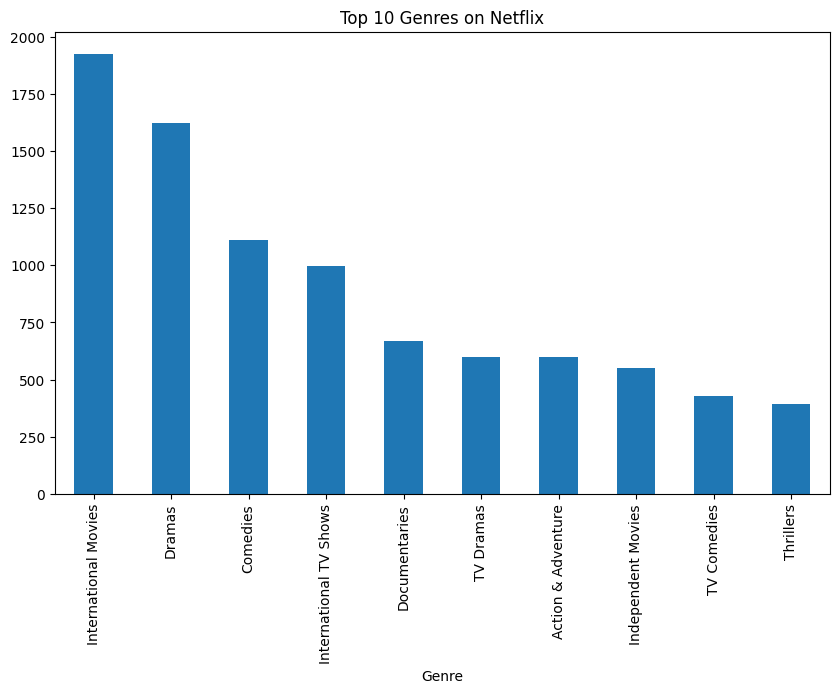

In [83]:
genre = data['listed_in'].str.split(',').explode().str.strip()
print(genre.value_counts().head(10))

plt.figure(figsize=(10, 6))
genre.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.savefig("Top 10 Genres on Netflix.png")
plt.xlabel("Genre")


listed_in
Romantic Movies       1200.000000
Action & Adventure    1033.333333
Classic Movies         800.000000
Cult Movies            700.000000
Horror Movies          500.000000
Korean TV Shows        500.000000
Reality TV             500.000000
Sci-Fi & Fantasy       475.000000
Anime Series           400.000000
Thrillers              375.000000
dtype: float64


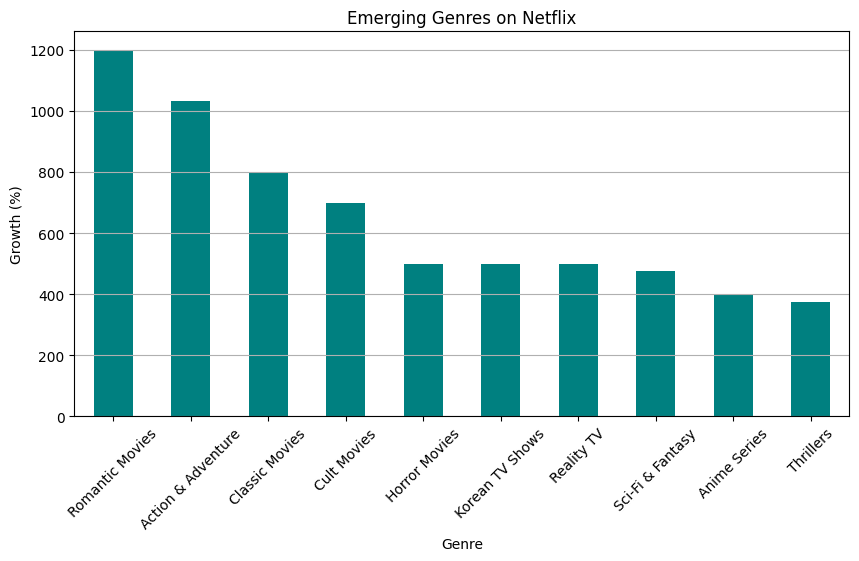

In [82]:
genres = data[['Year_added', 'listed_in']].dropna()

genres['listed_in'] = genres['listed_in'].str.split(', ')
genres = genres.explode('listed_in')

genre_trend = genres.groupby(['Year_added', 'listed_in']).size().unstack(fill_value=0)

early = genre_trend.loc[genre_trend.index <= 2015].sum()
recent = genre_trend.loc[genre_trend.index >= 2020].sum()

growth = ((recent - early) / early.replace(0, 1)) * 100

emerging_genres = growth.sort_values(ascending=False).head(10)
print(emerging_genres)
emerging_genres.plot(kind='bar', figsize=(10,5), color='teal')

plt.title("Emerging Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.savefig("Emerging Genres on Netflix.png")
plt.show()
